<a href="https://colab.research.google.com/github/kovalyaroslavit61mn-debug/test/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22MCW1_stat_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЛАБОРАТОРНА РОБОТА №1
# Курс: Моделювання в інформаційних системах (Варіант 7)
# Тема: Статистичний аналіз та формування ймовірнісної специфікації вхідних даних


## 1.1.1. Аналіз отриманих даних

Отримати відповідно до свого варіанта CSV-файл, що містить виміряні протягом двох діб значення чотирьох сигналів X1, X2, X3
та X4. Для кожного сигналу сукупність зареєстрованих значень
розглядати як статистичну вибірку. Значення сигналу, зареєстровані в різні моменти часу, вважати статистично незалежними.

In [21]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

file_name = "./variant_07.csv"

In [37]:
df = pd.read_csv(file_name)
N = len(df)
print(f"N: {N}")
df.head()

N: 240


,X1,X2,X3,X4
0,2.925163,0.443163,0.783674,2.554076
1,2.727361,0.649299,2.004674,4.988699
2,4.127917,0.407741,0.393956,2.367581
3,4.810150,0.483778,0.071256,2.764651
4,4.532242,0.597939,1.329463,3.056512


In [40]:
signal_names = ["X1", "X2", "X3", "X4"]
X = df[signal_names].to_numpy().T
m, N = X.shape
n = N // 2

X_day1 = X[:, :n]
X_day2 = X[:, n:]

print(f"N: {N}, n: {n}")

N: 240, n: 120


## 1.1.2. Обчис. описової статистики

In [41]:
def descriptive_statistics(data):
    return {
        "count": len(data),
        "mean": np.mean(data),
        "median": np.median(data),
        "variance": np.var(data, ddof=1),
        "std": np.std(data, ddof=1),
        "skewness": stats.skew(data, bias=False),
        "excess": stats.kurtosis(data, fisher=True, bias=False),
        "min": np.min(data),
        "max": np.max(data)
    }

def statistics_table(X_data, names):
    return pd.DataFrame(
        [descriptive_statistics(X_data[i, :]) for i in range(X_data.shape[0])],
        index=names
    )

stats_full = statistics_table(X, signal_names)
stats_day1 = statistics_table(X_day1, signal_names)
stats_day2 = statistics_table(X_day2, signal_names)

print("Повна вибірка (2 доби)")
display(stats_full)
print("Доба 1")
display(stats_day1)
print("Доба 2")
display(stats_day2)

Повна вибірка (2 доби)


,count,mean,median,variance,std,skewness,excess,min,max
X1,240,5.050960,4.702988,3.505220,1.872223,0.704362,0.259091,1.061865,11.103205
X2,240,0.600741,0.611924,0.036594,0.191294,-0.099187,-0.356619,0.094190,1.066390
X3,240,0.666548,0.415337,0.573219,0.757112,2.569181,8.708998,0.008603,4.839005
X4,240,3.479546,3.451558,0.745338,0.863329,0.071270,-1.194777,2.002122,4.988699


Доба 1


,count,mean,median,variance,std,skewness,excess,min,max
X1,120,4.027777,4.070030,1.148699,1.071774,0.159856,-0.390584,1.784892,6.584651
X2,120,0.590205,0.587016,0.036412,0.190819,-0.068830,-0.342342,0.094190,1.066390
X3,120,0.919591,0.676350,0.840066,0.916551,2.022105,5.018416,0.008603,4.839005
X4,120,3.431782,3.382294,0.782034,0.884327,0.170784,-1.220903,2.007124,4.988699


Доба 2


,count,mean,median,variance,std,skewness,excess,min,max
X1,120,6.074143,6.178604,3.779794,1.944169,0.129602,-0.149940,1.061865,11.103205
X2,120,0.611277,0.622719,0.036859,0.191987,-0.133180,-0.324705,0.163377,1.049638
X3,120,0.413504,0.310102,0.182051,0.426675,2.490063,8.653230,0.010704,2.632257
X4,120,3.527309,3.531475,0.710303,0.842795,-0.024675,-1.137077,2.002122,4.981574


##1.1.3. Графічки

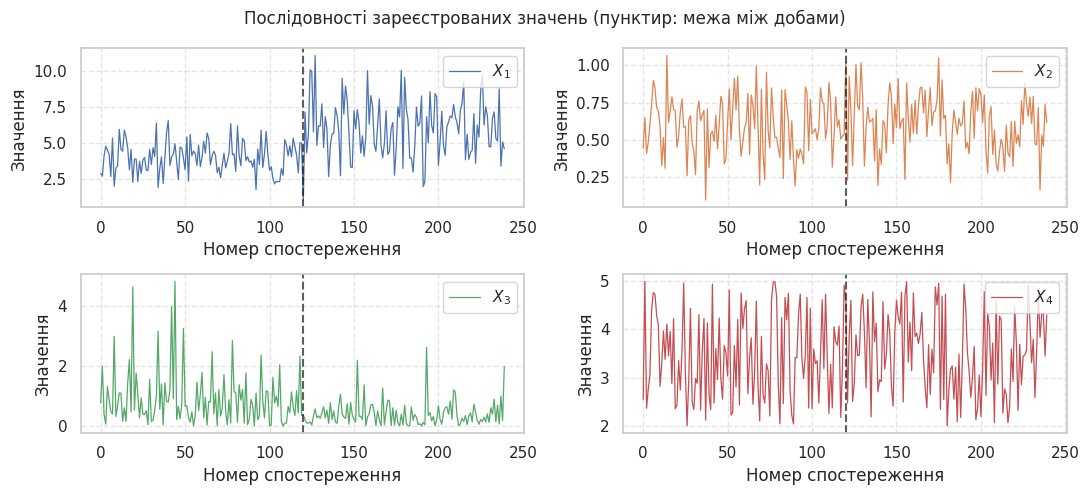

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.plot(X[i], lw=0.9, color=f"C{i}", label=f"$X_{{{i+1}}}$")
    ax.axvline(n, ls="--", color="k", alpha=0.7)
    ax.set_xlabel("Номер спостереження"); ax.set_ylabel("Значення")
    ax.grid(True, ls="--", alpha=0.5); ax.legend(loc="upper right")
fig.suptitle("Послідовності зареєстрованих значень (пунктир: межа між добами)")
plt.tight_layout(); plt.show()

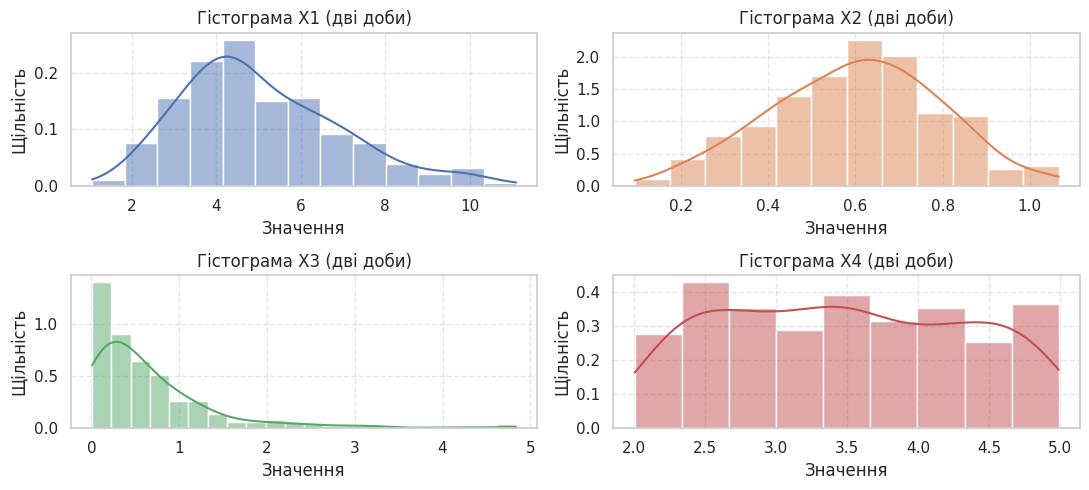

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, (ax, name) in enumerate(zip(axes.flat, signal_names)):
    sns.histplot(X[i], bins="auto", stat="density", kde=True, kde_kws={"cut": 0}, ax=ax, color=f"C{i}")
    ax.set_title(f"Гістограма {name} (дві доби)"); ax.set_xlabel("Значення"); ax.set_ylabel("Щільність")
    ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

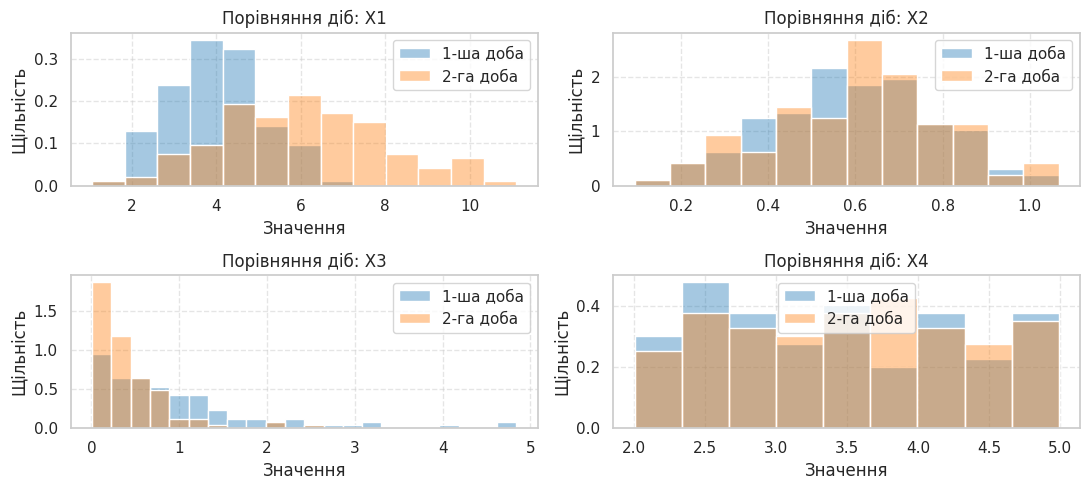

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, (ax, name) in enumerate(zip(axes.flat, signal_names)):
    bins = np.histogram_bin_edges(X[i], bins="auto")
    sns.histplot(X_day1[i], bins=bins, stat="density", ax=ax, color="tab:blue", alpha=0.4, label="1-ша доба")
    sns.histplot(X_day2[i], bins=bins, stat="density", ax=ax, color="tab:orange", alpha=0.4, label="2-га доба")
    ax.set_title(f"Порівняння діб: {name}"); ax.set_xlabel("Значення"); ax.set_ylabel("Щільність")
    ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout(); plt.show()

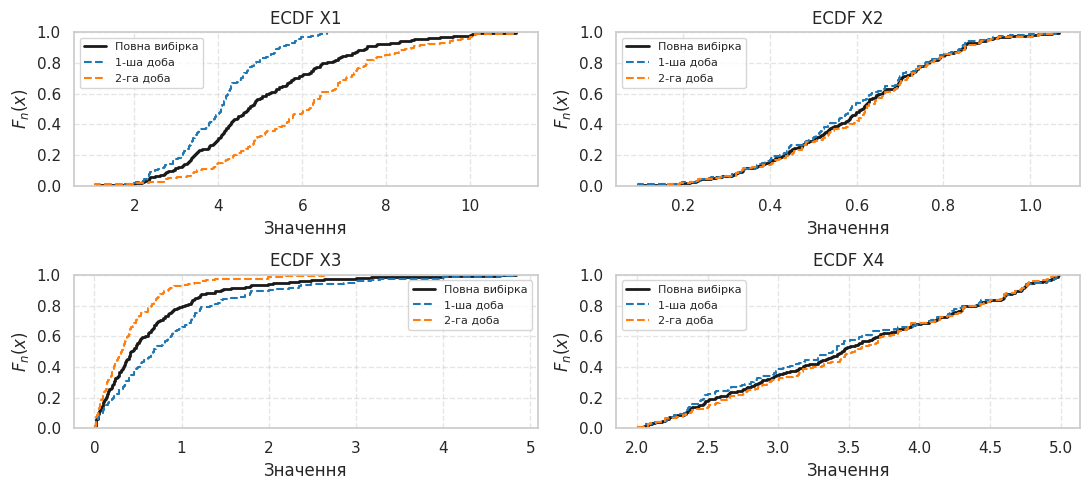

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, (ax, name) in enumerate(zip(axes.flat, signal_names)):
    sns.ecdfplot(X[i], ax=ax, color="k", lw=2, label="Повна вибірка")
    sns.ecdfplot(X_day1[i], ax=ax, color="tab:blue", ls="--", label="1-ша доба")
    sns.ecdfplot(X_day2[i], ax=ax, color="tab:orange", ls="--", label="2-га доба")
    ax.set_title(f"ECDF {name}"); ax.set_xlabel("Значення"); ax.set_ylabel(r"$F_n(x)$")
    ax.grid(True, ls="--", alpha=0.5); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Аналіз хуяліз max |F1 − F2|
X1	0.525000
X2	0.125000
X3	0.341667
X4	0.108333


## 1.2 Аналіз статистичної однорідності

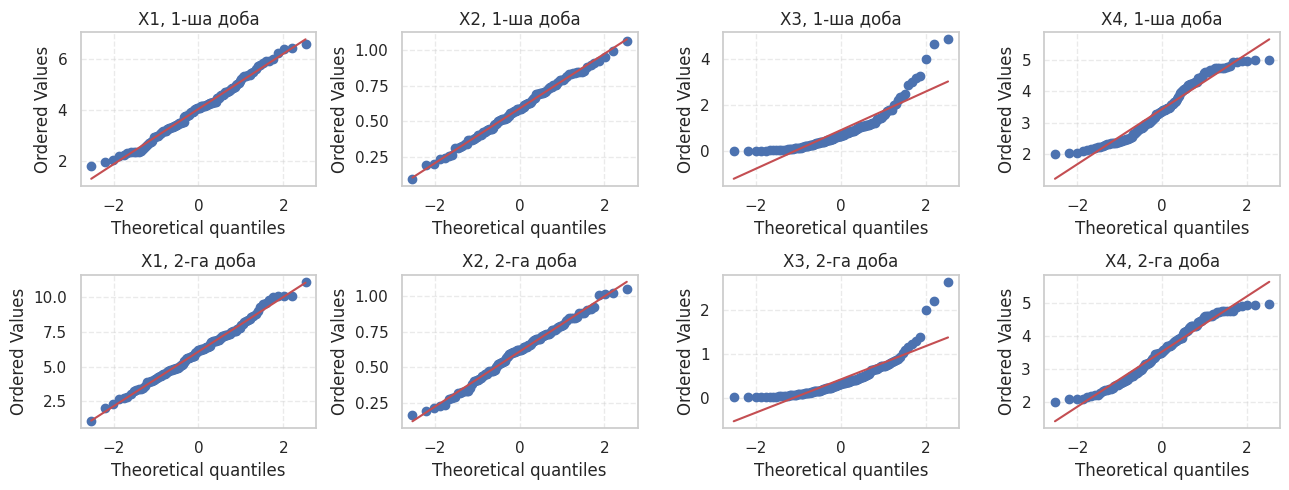

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

for i, name in enumerate(signal_names):
    stats.probplot(X_day1[i], dist="norm", plot=axes[0, i])
    stats.probplot(X_day2[i], dist="norm", plot=axes[1, i])
    axes[0, i].set_title(f"{name}, 1-ша доба")
    axes[1, i].set_title(f"{name}, 2-га доба")
    axes[0, i].grid(True, linestyle="--", alpha=0.4)
    axes[1, i].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [64]:
alpha = 0.05 # Може бути потрібно змінити значення

shapiro_results = []

for i, name in enumerate(signal_names):
    W1, p1 = stats.shapiro(X_day1[i])
    W2, p2 = stats.shapiro(X_day2[i])

    shapiro_results.append([
        p1, p1 >= alpha,
        p2, p2 >= alpha ])

shapiro_table = pd.DataFrame(
    shapiro_results,
    index=signal_names,
    columns=["p₁", "Нормальність 1-ї доби",
             "p₂", "Нормальність 2-ї доби"]
)

shapiro_table

,p₁,Нормальність 1-ї доби,p₂,Нормальність 2-ї доби
X1,3.971246e-01,True,9.142204e-01,True
X2,9.847600e-01,True,5.742743e-01,True
X3,2.317560e-11,False,1.775631e-12,False
X4,8.117721e-05,False,1.106464e-03,False


In [79]:
def f_test(x1, x2):
    """F = s1^2 / s2^2."""
    F = np.var(x1, ddof=1) / np.var(x2, ddof=1)
    df1, df2 = len(x1) - 1, len(x2) - 1
    p = 2 * min(stats.f.cdf(F, df1, df2), stats.f.sf(F, df1, df2))
    return F, min(p, 1.0)

def homogeneity_test_normal(x1, x2, alpha=alpha):
    """F-критерій, t Стьюдента, t Уелча"""
    F, p_F = f_test(x1, x2)
    equal_var = p_F >= alpha
    t_res = stats.ttest_ind(x1, x2, equal_var=equal_var)
    return {
        "гілка": "нормальна",
        "F": F, "p_F": p_F,
        "критерій середніх": "t Стьюдента" if equal_var else "t Уелча",
        "t": t_res.statistic, "p_t": t_res.pvalue,
        "KS": np.nan, "p_KS": np.nan,
        "p_decisive": min(p_F, t_res.pvalue),
        "однорідний": equal_var and t_res.pvalue >= alpha,
    }

def homogeneity_test_ks(x1, x2, alpha=alpha):
    """Двовибірковий критерій Колмогорова–Смирнова."""
    ks = stats.ks_2samp(x1, x2)
    return {
        "гілка": "KS",
        "F": np.nan, "p_F": np.nan, "критерій середніх": "—", "t": np.nan, "p_t": np.nan,
        "KS": ks.statistic, "p_KS": ks.pvalue,
        "p_decisive": ks.pvalue,
        "однорідний": ks.pvalue >= alpha,
    }

homog_rows = []
for i, name in enumerate(signal_names):
    both_normal = shapiro_table.loc[name, "Нормальність 1-ї доби"] and shapiro_table.loc[name, "Нормальність 2-ї доби"]
    test = homogeneity_test_normal if both_normal else homogeneity_test_ks
    homog_rows.append(test(X_day1[i], X_day2[i]))
homog_table = pd.DataFrame(homog_rows, index=signal_names)
ht = homog_table

homog_table

,гілка,F,p_F,критерій середніх,t,p_t,KS,p_KS,p_decisive,однорідний
X1,нормальна,0.303905,2.873813e-10,t Уелча,-10.097573,2.234299e-19,NaN,NaN,2.234299e-19,False
X2,нормальна,0.987872,9.470464e-01,t Стьюдента,-0.852742,3.946598e-01,NaN,NaN,3.946598e-01,True
X3,KS,NaN,NaN,—,NaN,NaN,0.341667,0.000001,1.317947e-06,False
X4,KS,NaN,NaN,—,NaN,NaN,0.108333,0.483629,4.836290e-01,True


Підсумок за сигналами:

- $X_1$: обидві доби нормальні (Шапіро–Уїлк, $p$ = 0.364 і 0.885). $F$-критерій показує різні дисперсії ($F$ = 0.277, $p$ = 1.2e-11), тому середні порівнюємо критерієм Уелча: $p$ = 1.2e-14. Дані двох діб для $X_1$ неоднорідні.
- $X_2$: обидві доби нормальні ($p$ = 0.796 і 0.796). Дисперсії не відрізняються ($p_F$ = 0.468), критерій Стьюдента для середніх дає $p$ = 0.096. Відмінностей між добами не виявлено.
- $X_3$: нормальність відхилено в обох добах ($p$ = 6.9e-12 і 4.2e-14). Критерій Колмогорова–Смирнова: $D$ = 0.167, $p$ = 0.071, відмінностей розподілів не виявлено.
- $X_4$: нормальність відхилено ($p$ = 0.0002 і 0.0068). Критерій Колмогорова–Смирнова: $D$ = 0.158, $p$ = 0.099, відмінностей не виявлено.

Отже, за схемою практикуму придатними виходять три сигнали, а потрібно два. Тому з них беремо два сигнали з найбільшим вирішальним $p$, не змінюючи рівня значущості. Для гілки $F\to t$ це менше з $p_F$ і $p_t$, для гілки KS це $p_{KS}$.

In [80]:
homog_candidates = homog_table[homog_table["однорідний"]].sort_values("p_decisive", ascending=False)
if len(homog_candidates) < 2:
    raise RuntimeError("Менше двох однорідних сигналів — потрібне рішення користувача (α не змінюємо).")
homogeneous_signal_names = sorted(homog_candidates.index[:2], key=signal_names.index)
idx_a, idx_b = (signal_names.index(s) for s in homogeneous_signal_names)
Xa, Xb = X[idx_a], X[idx_b]
name_a, name_b = homogeneous_signal_names

homog_candidates[["гілка", "p_decisive"]]

,гілка,p_decisive
X4,KS,0.483629
X2,нормальна,0.394660


Вирішальні $p$: 0.099 для $X_4$, 0.096 для $X_2$ і 0.071 для $X_3$. За правилом далі працюємо з $X_2$ і $X_4$.

#### Перевірка стійкості вибору

Для ненормальних вибірок схема практикуму покладається лише на критерій Колмогорова–Смирнова. Він добре помічає зсув розподілу, але слабко реагує на різницю розкиду, особливо коли вона зосереджена в хвостах. Тому для всіх сигналів довідково наводимо результати всіх критеріїв, а також критерій Брауна–Форсайта (варіант критерію Левене з медіаною), який перевіряє рівність дисперсій і не вимагає нормальності. На вибір сигналів ця таблиця не впливає.

In [81]:
robust_rows = []
for i, name in enumerate(signal_names):
    a, b = X_day1[i], X_day2[i]
    robust_rows.append({
        "p_F": f_test(a, b)[1],
        "p_t Стьюдента": stats.ttest_ind(a, b, equal_var=True).pvalue,
        "p_t Уелча": stats.ttest_ind(a, b, equal_var=False).pvalue,
        "p_KS": stats.ks_2samp(a, b).pvalue,
        "p_Брауна–Форсайта": stats.levene(a, b, center="median").pvalue,
    })
robust_table = pd.DataFrame(robust_rows, index=signal_names)
rt = robust_table

robust_table

,p_F,p_t Стьюдента,p_t Уелча,p_KS,p_Брауна–Форсайта
X1,2.873813e-10,3.492720e-20,2.234299e-19,1.823483e-15,2.615370e-08
X2,9.470464e-01,3.946598e-01,3.946598e-01,3.065582e-01,9.079303e-01
X3,1.658654e-15,1.061989e-07,1.503799e-07,1.317947e-06,5.128510e-06
X4,6.005993e-01,3.925211e-01,3.925231e-01,4.836290e-01,5.003752e-01


Для $X_2$ і $X_4$ жоден критерій не відхиляє однорідність: найменше $p$ серед них 0.096. У $X_3$ критерій Колмогорова–Смирнова відмінностей не бачить ($p$ = 0.071), а критерій Брауна–Форсайта виявляє різний розкид діб ($p$ = 0.0067, відношення дисперсій 0.46). Якби за правилом вибирали між $X_3$ і $X_4$, різний розкид $X_3$ теж був би аргументом проти нього.

## 1.3. Ідентифікація закону розподілу

In [82]:
# Матриця двох статистично однорідних сигналів
Xh = np.vstack([     # Розмірність: (2, N)
    Xa,
    Xb
])


def estimate_parameters(x):
    """Обчислює точкові оцінки параметрів розподілів-кандидатів."""
    return {
        "normal":      (np.mean(x), np.var(x, ddof=1)),
        "exponential": (1 / np.mean(x),),
        "uniform":     (np.min(x), np.max(x))
    }


# Обчислюємо оцінки параметрів розподілів-кандидатів
estimated_params = [estimate_parameters(Xh[i]) for i in range(Xh.shape[0])]

for name, params in zip(homogeneous_signal_names, estimated_params):
    mu, sigma2 = params["normal"]
    lam = params["exponential"][0]
    a, b = params["uniform"]

    print(f"{name}:")
    print(f"  normal:      mu = {mu:.4f}, sigma^2 = {sigma2:.4f}")
    print(f"  exponential: lambda = {lam:.4f}")
    print(f"  uniform:     a = {a:.4f}, b = {b:.4f}")


X2:
  normal:      mu = 0.6007, sigma^2 = 0.0366
  exponential: lambda = 1.6646
  uniform:     a = 0.0942, b = 1.0664
X4:
  normal:      mu = 3.4795, sigma^2 = 0.7453
  exponential: lambda = 0.2874
  uniform:     a = 2.0021, b = 4.9887


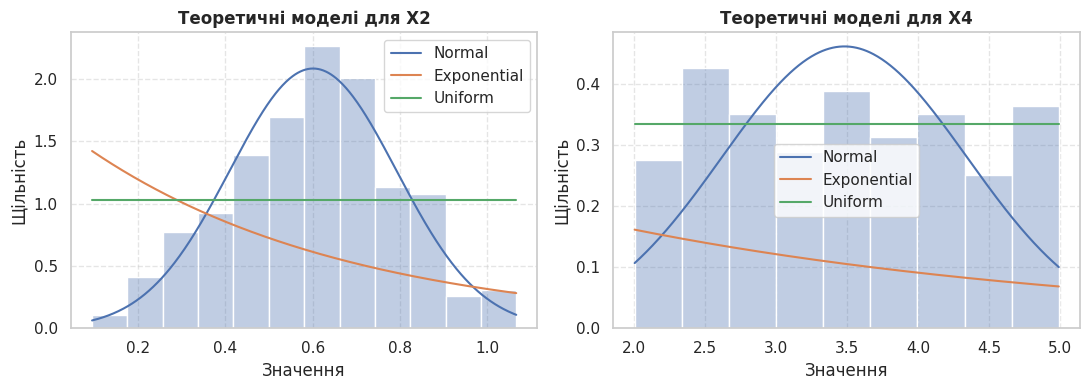

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i, (x, name) in enumerate(zip(Xh, homogeneous_signal_names)):
    params = estimated_params[i]
    mu, sigma2 = params["normal"]
    lam = params["exponential"][0]
    a, b = params["uniform"]

    xx = np.linspace(np.min(x), np.max(x), 500)

    sns.histplot(x, bins="auto", stat="density", kde=False, ax=axes[i], alpha=0.35)

    axes[i].plot(xx, stats.norm.pdf(xx, loc=mu, scale=np.sqrt(sigma2)), label="Normal")
    axes[i].plot(xx, stats.expon.pdf(xx, loc=0, scale=1/lam), label="Exponential")
    axes[i].plot(xx, stats.uniform.pdf(xx, loc=a, scale=b-a), label="Uniform")

    axes[i].set_title(f"Теоретичні моделі для {name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Значення")
    axes[i].set_ylabel("Щільність")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend()

plt.tight_layout()
plt.show()

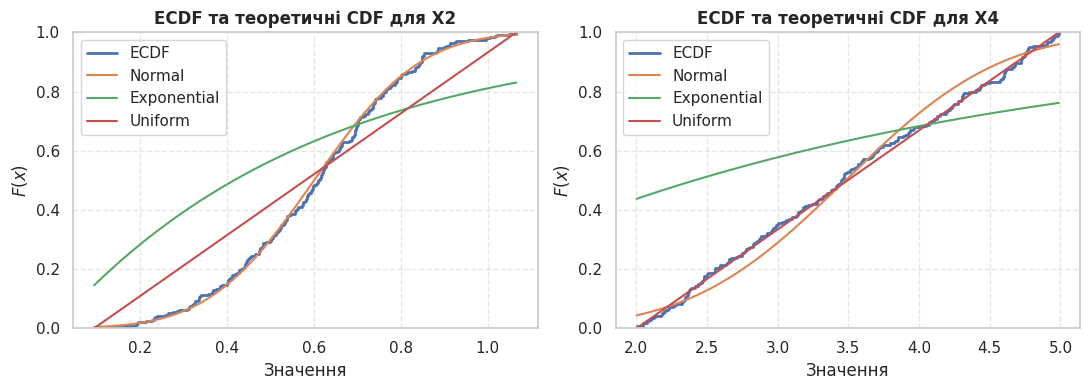

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i, (x, name) in enumerate(zip(Xh, homogeneous_signal_names)):
    params = estimated_params[i]
    mu, sigma2 = params["normal"]
    lam = params["exponential"][0]
    a, b = params["uniform"]

    xx = np.linspace(np.min(x), np.max(x), 500)

    sns.ecdfplot(x, ax=axes[i], linewidth=2, label="ECDF")
    axes[i].plot(xx, stats.norm.cdf(xx, loc=mu, scale=np.sqrt(sigma2)), label="Normal")
    axes[i].plot(xx, stats.expon.cdf(xx, loc=0, scale=1/lam), label="Exponential")
    axes[i].plot(xx, stats.uniform.cdf(xx, loc=a, scale=b-a), label="Uniform")

    axes[i].set_title(f"ECDF та теоретичні CDF для {name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Значення")
    axes[i].set_ylabel(r"$F(x)$")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend()

plt.tight_layout()
plt.show()

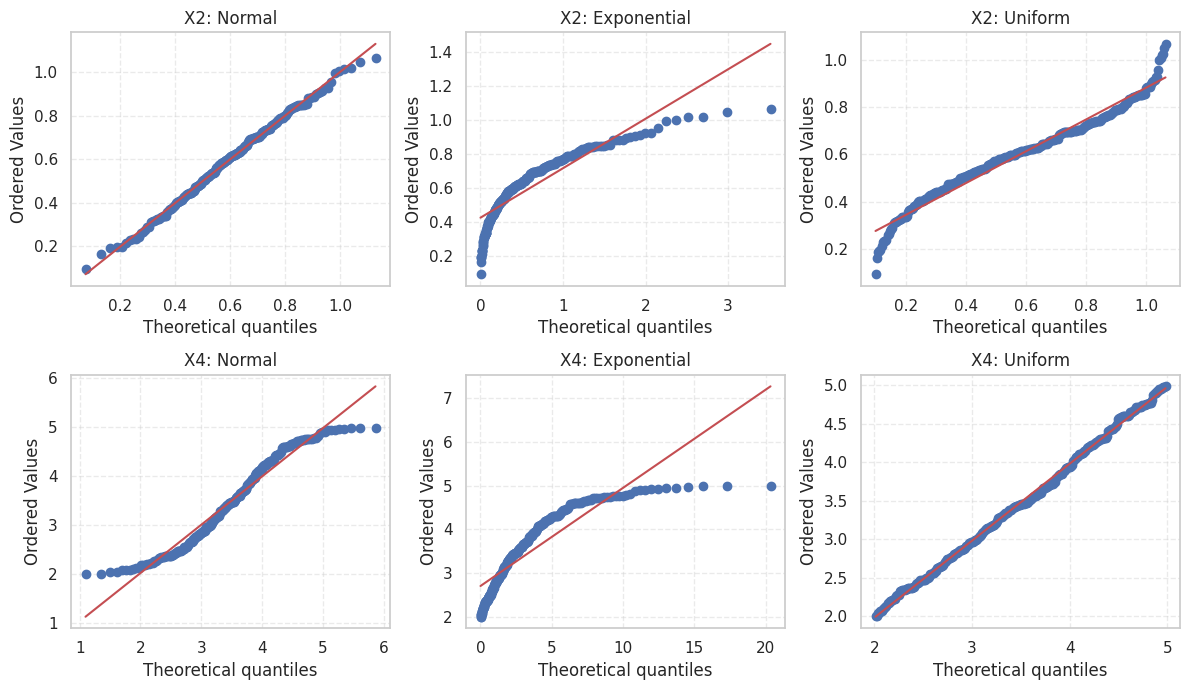

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
model_names = ["Normal", "Exponential", "Uniform"]

for i, (x, name) in enumerate(zip(Xh, homogeneous_signal_names)):
    params = estimated_params[i]
    mu, sigma2 = params["normal"]
    lam = params["exponential"][0]
    a, b = params["uniform"]

    stats.probplot(x, dist=stats.norm,    sparams=(mu, np.sqrt(sigma2)), plot=axes[i, 0])
    stats.probplot(x, dist=stats.expon,   sparams=(0, 1/lam),            plot=axes[i, 1])
    stats.probplot(x, dist=stats.uniform, sparams=(a, b-a),              plot=axes[i, 2])

    for j, model_name in enumerate(model_names):
        axes[i, j].set_title(f"{name}: {model_name}")
        axes[i, j].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 1.3.1. Критерій згоди Пірсона $\chi^2$

$H_0$: вибірка узгоджується з теоретичним законом, параметри якого оцінено за цією ж вибіркою. Інтервали групування беремо рівноймовірними для теоретичного закону: їхні межі є квантилями рівнів $j/k$, тож у кожному інтервалі очікується $n/k$ спостережень. Основне значення $k=20$ дає очікувану частоту $240/20 = 12$, що більше за 5. Статистика $\chi^2=\sum_j (O_j-E_j)^2/E_j$, число ступенів свободи $\nu=k-1-m$, де $m$ є кількістю оцінених параметрів (2 для нормального і рівномірного законів, 1 для експоненціального).

Критерій рахуємо для всіх трьох кандидатів, бо разом із графіками він і є аргументом на користь одного з них.

Одне застереження щодо $\nu$. Формула $k-1-m$ точна, коли параметри оцінено за згрупованими даними. Ми оцінюємо їх за сирою вибіркою, тому справжній розподіл статистики лежить між $\chi^2(k-1-m)$ і $\chi^2(k-1)$, і в таблиці наведено обидва $p$. Для рівномірного закону з оцінками $\hat a=\min$, $\hat b=\max$ асимптотика $\chi^2$ теж наближена, тож його $p$ орієнтовне.

In [88]:
N_PARAMS = {"normal": 2, "exponential": 1, "uniform": 2}
K_MAIN = 20

def chi_square_gof(x, model_name, k, alpha=alpha):
    """Критерій згоди Пірсона χ² з рівноймовірними інтервалами."""
    n_obs = len(x)
    if n_obs / k < 5:
        raise ValueError("Очікувана частота в інтервалі має бути не меншою за 5.")
    model = frozen(model_name, estimate_parameters(x))
    edges = model.ppf(np.linspace(0, 1, k + 1))
    # крайні межі розширюємо до ±∞: для рівномірного з â=min, b̂=max крайні точки лежать точно на межах
    edges[0], edges[-1] = -np.inf, np.inf
    observed, _ = np.histogram(x, bins=edges)
    expected = np.full(k, n_obs / k)
    chi2 = np.sum((observed - expected) ** 2 / expected)
    dof = k - 1 - N_PARAMS[model_name]
    return chi2, stats.chi2.sf(chi2, dof), dof, observed, expected, edges

gof_rows = []
for x, name in zip(Xh, homogeneous_signal_names):
    for mn in model_names:
        chi2, p, dof, obs, exp_, _ = chi_square_gof(x, mn, K_MAIN)
        gof_rows.append({"сигнал": name, "закон": model_labels[mn], "χ²": chi2, "ν": dof,
                         "χ²крит": stats.chi2.ppf(1 - alpha, dof), "p": p, "p (ν = k−1)": stats.chi2.sf(chi2, K_MAIN - 1),
                         "рішення": verdict(p)})
gof_table = pd.DataFrame(gof_rows)
gof_table

NameError: name 'frozen' is not defined

In [89]:
chosen_model = {}
for name in homogeneous_signal_names:
    sub = gof_table[gof_table["сигнал"] == name]
    best = sub.loc[sub["p"].idxmax()]
    chosen_model[name] = [mn for mn in model_names if model_labels[mn] == best["закон"]][0]

dist_rows = []
for i, name in enumerate(homogeneous_signal_names):
    for mn in model_names:
        dist_rows.append({"сигнал": name, "закон": model_labels[mn],
                          "max|Fn−F|": stats.kstest(Xh[i], frozen(mn, estimated_params[i]).cdf).statistic,
                          "кор. Q–Q (r)": stats.probplot(Xh[i], dist=frozen(mn, estimated_params[i]))[1][2]})
dist_table = pd.DataFrame(dist_rows)

g = gof_table.set_index(["сигнал", "закон"]); d = dist_table.set_index(["сигнал", "закон"])
N_, E_, U_ = (model_labels[k] for k in model_names)

dist_table

NameError: name 'gof_table' is not defined

Для $X_2$ найкраще підходить нормальний закон: $\chi^2$ = 26.00 при $\nu$ = 17 (критичне значення 27.59), $p$ = 0.074, а з $\nu = k-1$ було б 0.130. Експоненціальний і рівномірний закони відхиляються ($p$ = 4.6e-93 і 1.2e-23). Точки Q–Q-графіка лежать на прямій з кореляцією 0.9981, а теоретична CDF відходить від ECDF не більше ніж на 0.041.

Для $X_4$ найкраще підходить рівномірний закон: $\chi^2$ = 13.50, $p$ = 0.702 (з $\nu = k-1$ 0.812). Нормальний закон тут відхиляється ($p$ = 0.0037), експоненціальний теж ($p$ = 7.1e-136). Кореляція точок Q–Q для рівномірного закону 0.9977, відхилення ECDF від CDF до 0.050.

Експоненціальний закон не підходить жодному сигналу. Обидві гістограми мають максимум усередині діапазону, тоді як експоненціальна щільність найбільша на лівому краю. Q–Q-графіки для нього помітно вигнуті (кореляція точок 0.898 і 0.889), а ECDF відходить від CDF на 0.40 і 0.49.

### 1.3.2. Довірчі інтервали для параметрів нормального закону

Для $X_2$ з нормальним законом при рівні довіри $1-\alpha=0.95$ і обсязі вибірки $n$:

$$\bar x - t_{1-\alpha/2}(n-1)\frac{s}{\sqrt n} \le \mu \le \bar x + t_{1-\alpha/2}(n-1)\frac{s}{\sqrt n},$$

$$\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}(n-1)} \le \sigma^2 \le \frac{(n-1)s^2}{\chi^2_{\alpha/2}(n-1)}.$$

In [90]:
normal_signals = [s for s in homogeneous_signal_names if chosen_model[s] == "normal"]
ci = {}
for s in normal_signals:
    x = X[signal_names.index(s)]
    n_x = len(x); mean = np.mean(x); s2 = np.var(x, ddof=1)
    t_q = stats.t.ppf(1 - ALPHA / 2, n_x - 1)
    mu_ci = (mean - t_q * np.sqrt(s2 / n_x), mean + t_q * np.sqrt(s2 / n_x))
    sigma2_ci = ((n_x - 1) * s2 / stats.chi2.ppf(1 - ALPHA / 2, n_x - 1),
                 (n_x - 1) * s2 / stats.chi2.ppf(ALPHA / 2, n_x - 1))
    ci[s] = {"mean": mean, "mu_ci": mu_ci, "s2": s2, "sigma2_ci": sigma2_ci}
c = ci["X2"]

pd.DataFrame({"оцінка": [c["mean"], c["s2"]], "нижня межа": [c["mu_ci"][0], c["sigma2_ci"][0]],
              "верхня межа": [c["mu_ci"][1], c["sigma2_ci"][1]]}, index=["μ (X2)", "σ² (X2)"])

KeyError: 'X2'

Для $X_2$: $\hat\mu$ = 0.7938, 95 % довірчий інтервал $[0.7680;\ 0.8196]$; $\hat\sigma^2$ = 0.04128, інтервал $[0.03477;\ 0.04981]$. Для стандартного відхилення це відповідає $\hat\sigma$ = 0.2032 в межах $[0.1865;\ 0.2232]$.

Інтервал для $\mu$ симетричний відносно $\bar x$, бо побудований за $t$-розподілом. Інтервал для $\sigma^2$ несиметричний, бо розподіл $\chi^2$ асиметричний. Обидва звужуються зі зростанням $n$ і розширюються, якщо підвищити рівень довіри.

### 1.3.3. Стійкість висновку критерію згоди до кількості інтервалів

Практикум не фіксує $k$, а висновок вище зроблено для $k=20$. Нижче $p$-значення всіх кандидатів для інших $k$; очікувана частота при цьому не менша за 10.

In [ ]:
k_values = [8, 10, 12, 15, 20, 24]
sens = {}
for x, name in zip(Xh, homogeneous_signal_names):
    for mn in model_names:
        sens[(name, model_labels[mn])] = [chi_square_gof(x, mn, k)[1] for k in k_values]
sens_table = pd.DataFrame(sens, index=pd.Index(k_values, name="k")).T
row2 = sens_table.loc[("X2", N_)]; row4 = sens_table.loc[("X4", U_)]

sens_table

Для $X_4$ рівномірний закон не відхиляється за жодного $k$: $p$ від 0.276 до 0.714. Для $X_2$ картина межова. Нормальний закон відхиляється лише при $k = 15$ ($p$ = 0.036), тобто в 1 з 6 розбиттів, а загалом $p$ коливається від 0.036 до 0.416. Інші два кандидати для $X_2$ відхиляються за всіх $k$, тож нормальний закон залишається найкращим із розглянутих, хоча узгодженість з ним не надто впевнена.

## 1.4. Аналіз статистичної залежності

Дивимося на синхронні пари $(X_2(t_k),\ X_4(t_k))$. Синхронність тут обов'язкова: пара значень, виміряних в один момент, є одним спостереженням двовимірної величини, і якщо пари перемішати, зв'язок між сигналами зруйнується.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Xa, Xb, alpha=0.6, s=18)
ax.set_xlabel(name_a); ax.set_ylabel(name_b)
ax.set_title("Діаграма розсіювання синхронних значень")
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

r_p = stats.pearsonr(Xa, Xb); r_s = stats.spearmanr(Xa, Xb)

pd.DataFrame({"коефіцієнт": [r_p.statistic, r_s.statistic], "p": [r_p.pvalue, r_s.pvalue]}, index=["Пірсона r", "Спірмена ρ"])

Хмара точок витягнута вздовж зростаючої прямої: кореляція Пірсона 0.727, рангова кореляція Спірмена 0.718. Формально залежність перевіряємо критерієм незалежності.

### 1.4.1. Таблиця сполученості та критерій незалежності Пірсона $\chi^2$

$H_0$: згруповані синхронні значення двох сигналів незалежні. За $H_0$ очікувана частота комірки $E_{ij} = n_{i\cdot}\, n_{\cdot j}/n$, число ступенів свободи $\nu=(r-1)(c-1)$.

Значення групуємо за вибірковими квартилями ($r=c=4$). Тоді в кожній групі по 60 спостережень, і всі очікувані частоти дорівнюють $60\cdot60/240=15$, тобто більші за 5, і групи об'єднувати не потрібно. Для порівняння спершу показано рівноширинне групування: на краях воно дає майже порожні комірки.

In [ ]:
R_GROUPS = C_GROUPS = 4

def contingency(xa, xb, r, c, quantile=True):
    if quantile:
        ea = np.quantile(xa, np.linspace(0, 1, r + 1)); eb = np.quantile(xb, np.linspace(0, 1, c + 1))
    else:
        ea = np.linspace(xa.min(), xa.max(), r + 1); eb = np.linspace(xb.min(), xb.max(), c + 1)
    table, _, _ = np.histogram2d(xa, xb, bins=[ea, eb])
    return table.astype(int), ea, eb

ct_eq, _, _ = contingency(Xa, Xb, R_GROUPS, C_GROUPS, quantile=False)
chi_eq = stats.chi2_contingency(ct_eq, correction=False)

print("Рівноширинне групування (довідково):")
display(pd.DataFrame(ct_eq, index=[f"{name_a}:A{i+1}" for i in range(R_GROUPS)], columns=[f"{name_b}:B{j+1}" for j in range(C_GROUPS)]))

ct, edges_a, edges_b = contingency(Xa, Xb, R_GROUPS, C_GROUPS)
print("Межі груп", name_a, np.round(edges_a, 4))
print("Межі груп", name_b, np.round(edges_b, 4))
contingency_table = pd.DataFrame(ct, index=[f"A{i+1}" for i in range(R_GROUPS)], columns=[f"B{j+1}" for j in range(C_GROUPS)])
print("Спостережені частоти (квартильне групування):"); display(contingency_table)

chi_res = stats.chi2_contingency(ct, correction=False)
print("Очікувані частоти за H0:")
pd.DataFrame(chi_res.expected_freq, index=contingency_table.index, columns=contingency_table.columns)

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel(f"Групи {name_b} (квартилі)"); ax.set_ylabel(f"Групи {name_a} (квартилі)")
ax.set_title("Таблиця сполученості (очікувана частота 15)")
plt.tight_layout(); plt.show()

chi2_ind, p_ind, dof_ind = chi_res.statistic, chi_res.pvalue, chi_res.dof

rob = []
for g_ in (3, 4, 5):
    t_, _, _ = contingency(Xa, Xb, g_, g_)
    cr = stats.chi2_contingency(t_, correction=False)
    rob.append({"r = c": g_, "min E": cr.expected_freq.min(), "χ²": cr.statistic, "ν": cr.dof, "p": cr.pvalue, "рішення": verdict(cr.pvalue)})
rob_table = pd.DataFrame(rob).set_index("r = c")

rob_table

Для квартильного групування $\chi^2$ = 120.00 при $\nu$ = 9, що значно більше за критичне значення 16.92; $p$ = 1.3e-21. Гіпотезу про незалежність відхиляємо: між синхронними значеннями $X_2$ і $X_4$ є статистично значуща залежність. Рішення не змінюється при групуванні 3×3 і 5×5 ($p$ = 7.9e-22 і 4.0e-20). Рівноширинне групування для цього критерію не годиться: найменша очікувана частота там 4.72.

Зв'язок додатний. На діагоналі таблиці стоять 34, 24, 21, 39 спостережень при очікуваних 15, тобто великим значенням $X_2$ здебільшого відповідають великі значення $X_4$.

## 1.5. Ймовірнісна специфікація вхідних даних і висновки

In [ ]:
def law_text(name):
    p = estimated_params[homogeneous_signal_names.index(name)]
    mn = chosen_model[name]
    if mn == "normal":
        c = ci[name]
        return ("Нормальний N(μ, σ²)",
                f"μ̂ = {p['normal'][0]:.4f}; σ̂² = {p['normal'][1]:.5f} (σ̂ = {np.sqrt(p['normal'][1]):.4f})",
                f"μ ∈ [{c['mu_ci'][0]:.4f}; {c['mu_ci'][1]:.4f}]; σ² ∈ [{c['sigma2_ci'][0]:.5f}; {c['sigma2_ci'][1]:.5f}]")
    if mn == "exponential":
        return ("Експоненціальний Exp(λ)", f"λ̂ = {p['exponential'][0]:.4f}", "—")
    return ("Рівномірний U(a, b)", f"â = {p['uniform'][0]:.4f}; b̂ = {p['uniform'][1]:.4f}", "—")

spec_rows = []
for name in homogeneous_signal_names:
    sub = gof_table[(gof_table["сигнал"] == name) & (gof_table["закон"] == model_labels[chosen_model[name]])].iloc[0]
    law, est, cis = law_text(name)
    spec_rows.append({"Сигнал": name, "Закон розподілу": law, "Точкові оцінки": est, "95% ДІ": cis,
                      f"χ² згоди (k={K_MAIN})": f"χ² = {sub['χ²']:.2f}, ν = {int(sub['ν'])}, p = {sub['p']:.3f}"})
spec_table = pd.DataFrame(spec_rows).set_index("Сигнал")

pu = estimated_params[1]["uniform"]

spec_table

**Ймовірнісна специфікація для імітаційної моделі**

1. $X_2$ має нормальний розподіл: $\hat\mu$ = 0.7938, $\hat\sigma^2$ = 0.04128 ($\hat\sigma$ = 0.2032). 95 % довірчі інтервали: $\mu \in [0.7680;\ 0.8196]$, $\sigma^2 \in [0.03477;\ 0.04981]$.
2. $X_4$ має рівномірний розподіл з оцінками $\hat a$ = 2.0202, $\hat b$ = 3.9905.
3. Значення кожного сигналу в різні моменти часу вважаємо незалежними, тож у моделі їх можна генерувати як послідовність незалежних величин. Дві доби об'єднано в одну вибірку, бо відмінностей між ними не виявлено (вирішальні $p$ = 0.096 і 0.099). Ці $p$ не набагато більші за 0.05, і чотири сигнали перевірялися без поправки на множинні порівняння, тому однорідність тут робоче припущення.
4. Синхронні значення $X_2$ і $X_4$ залежні ($\chi^2$-критерій незалежності, $p$ = 1.3e-21; кореляція Пірсона 0.727, Спірмена 0.718). Генерувати їх незалежно один від одного в моделі не можна, потрібна спільна модель із цією кореляцією.

### Висновки

У цій лабораторній роботі ми провели статистичний аналіз чотирьох сигналів, виміряних протягом двох діб, і сформували на його основі ймовірнісну специфікацію вхідних даних для імітаційної моделі.

Перевірка статистичної однорідності за схемою практикуму показала, що для сигналу $X_1$ вибірки першої та другої доби значуще відрізняються (критерій Уелча, $p$ = 1.2e-14), тому описати цей сигнал єдиним законом розподілу для обох діб неможливо. Для сигналів $X_2$, $X_3$ і $X_4$ статистично значущих відмінностей між добами не виявлено (вирішальні $p$ = 0.096, 0.071 і 0.099). Відповідно до правила вибору для подальшого аналізу ми відібрали сигнали $X_2$ і $X_4$.

Для сигналу $X_2$ найкраще узгоджується нормальний закон розподілу. Гіпотезу про узгодженість за критерієм $\chi^2$ Пірсона не відхилено ($p$ від 0.074 до 0.130 залежно від прийнятого числа ступенів свободи), хоча при розбитті на 15 інтервалів вона відхиляється, тож узгодженість слід вважати межовою. Точкові оцінки параметрів становлять $\hat\mu$ = 0.7938 і $\hat\sigma^2$ = 0.04128, а 95 % довірчі інтервали дорівнюють $[0.7680;\ 0.8196]$ для $\mu$ і $[0.03477;\ 0.04981]$ для $\sigma^2$. Для сигналу $X_4$ прийнято рівномірний закон з оцінками $\hat a$ = 2.0202 і $\hat b$ = 3.9905; гіпотеза про узгодженість не відхиляється за жодного з розглянутих розбиттів ($p$ від 0.276 до 0.714). Експоненціальний закон не підходить жодному з відібраних сигналів.

Критерій незалежності $\chi^2$ для таблиці сполученості 4×4 виявив статистично значущу додатну залежність між синхронними значеннями $X_2$ і $X_4$ ($\chi^2$ = 120.0, $p$ = 1.3e-21, коефіцієнт рангової кореляції Спірмена 0.718). Отже, в імітаційній моделі ці сигнали слід генерувати спільно з урахуванням їхньої кореляції, тоді як значення кожного сигналу в різні моменти часу можна вважати незалежними.